In [1]:
import sys
sys.path.append('../')
import karman
import pandas as pd
import torch
import numpy as np
import random
from torch.utils.data import RandomSampler, SequentialSampler
import pickle as pk
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

torch.set_default_dtype(torch.float32)


First the dataset:

In [2]:
lag_minutes=10000
resolution_minutes=100
features_to_exclude_thermo=["all__dates_datetime__", "tudelft_thermo__satellite__", "tudelft_thermo__ground_truth_thermospheric_density__[kg/m**3]", "all__year__[y]", "NRLMSISE00__thermospheric_density__[kg/m**3]"]
features_to_exclude_thermo+='celestrack__ap_average__,JB08__d_st_dt__[K],space_environment_technologies__f107_obs__,space_environment_technologies__f107_average__,space_environment_technologies__s107_obs__,space_environment_technologies__s107_average__,space_environment_technologies__m107_obs__,space_environment_technologies__m107_average__,space_environment_technologies__y107_obs__,space_environment_technologies__y107_average__'.split(',')

In [3]:
karman_dataset=karman.KarmanDataset(thermo_path='../data/satellites_data_w_sw_2mln.csv',
                                    min_date=pd.to_datetime('2000-07-29 00:59:47'),
                                    max_date=pd.to_datetime('2024-05-31 23:59:32'),
                                    normalization_dict=None,
                                    nrlmsise00_path='../data/nrlmsise00_data/nrlmsise00_time_series.csv',#[None if nrlmsise00_path=='None' else nrlmsise00_path][0],
                                    omni_indices_path='../data/omniweb_data/merged_omni_indices.csv',#[None if omni_indices_path=='None' else omni_indices_path][0],
                                    omni_magnetic_field_path='../data/omniweb_data/merged_omni_magnetic_field.csv',#[None if omni_magnetic_field_path=='None' else omni_magnetic_field_path][0],
                                    omni_solar_wind_path='../data/omniweb_data/merged_omni_solar_wind.csv',#[None if omni_solar_wind_path=='None' else omni_solar_wind_path][0],
                                    soho_path='../data/soho_data/soho_data.csv',#[None if soho_path=='None' else soho_path][0],
                                    lag_minutes_nrlmsise00=lag_minutes,
                                    nrlmsise00_resolution=resolution_minutes,
                                    lag_minutes_omni=lag_minutes,
                                    omni_resolution=resolution_minutes,
                                    lag_minutes_soho=lag_minutes,
                                    soho_resolution=resolution_minutes,
                                    features_to_exclude_thermo=features_to_exclude_thermo
                        )


Loading Omni indices.


/home/ga00693/2024-HL-Thermo-CL/notebooks/../karman/dataset.py:469: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.time_series_data[data_name]["data"] = self.time_series_data[data_name]["data"].interpolate(method="pad")
/home/ga00693/2024-HL-Thermo-CL/notebooks/../karman/dataset.py:472: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.time_series_data[data_name]["data"] = (self.time_series_data[data_name]["data"].resample(f"{resolution}T").ffill())


Loading Omni Solar Wind.


/home/ga00693/2024-HL-Thermo-CL/notebooks/../karman/dataset.py:469: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.time_series_data[data_name]["data"] = self.time_series_data[data_name]["data"].interpolate(method="pad")
/home/ga00693/2024-HL-Thermo-CL/notebooks/../karman/dataset.py:472: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.time_series_data[data_name]["data"] = (self.time_series_data[data_name]["data"].resample(f"{resolution}T").ffill())


Loading Omni Magnetic Field.


...

Loading SOHO.


/home/ga00693/2024-HL-Thermo-CL/notebooks/../karman/dataset.py:469: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.time_series_data[data_name]["data"] = self.time_series_data[data_name]["data"].interpolate(method="pad")
/home/ga00693/2024-HL-Thermo-CL/notebooks/../karman/dataset.py:472: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.time_series_data[data_name]["data"] = (self.time_series_data[data_name]["data"].resample(f"{resolution}T").ffill())


Creating thermospheric density dataset
Removing from the data errors in mean absolute percentage error 200% or more in the density (between nrlmsise00 and ground truth)
loading it from file
Used features: Index(['tudelft_thermo__altitude__[m]', 'tudelft_thermo__latitude__[deg]',
       'tudelft_thermo__longitude__[deg]_sin',
       'tudelft_thermo__longitude__[deg]_cos', 'all__day_of_year__[d]_sin',
       'all__day_of_year__[d]_cos', 'all__seconds_in_day__[s]_sin',
       'all__seconds_in_day__[s]_cos'],
      dtype='object')
Index(['tudelft_thermo__altitude__[m]', 'tudelft_thermo__latitude__[deg]',
       'tudelft_thermo__longitude__[deg]_sin',
       'tudelft_thermo__longitude__[deg]_cos', 'all__day_of_year__[d]_sin',
       'all__day_of_year__[d]_cos', 'all__seconds_in_day__[s]_sin',
       'all__seconds_in_day__[s]_cos'],
      dtype='object')
feature is: tudelft_thermo__altitude__[m]
feature is: tudelft_thermo__latitude__[deg]
Loading NRLMSISE00.


/home/ga00693/2024-HL-Thermo-CL/notebooks/../karman/dataset.py:497: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.time_series_data[data_name]["data"] = (self.time_series_data[data_name]["data"].resample(f"{resolution}T").ffill())



Finished Creating dataset.


In [4]:
with open("normalization_dict_ts.pk", "wb") as f:
    pk.dump(karman_dataset.normalization_dict,f)

In [5]:
with open("normalization_dict_ts.pk", "rb") as f:
    normalization_dict_ts=pk.load(f)

/home/ga00693/mambaforge/envs/karman_gpu/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


In [6]:
import pickle as pk
#let's store the scaler to a pickle file:
for key in karman_dataset.time_series_data.keys():
    #save the scaler as a pickle:
    with open(f'scaler_{key}.pk','wb') as f:
        pk.dump(karman_dataset.time_series_data['omni_indices']['scaler'],f)

In [7]:
#then to load it:
scalers_dict={}
for key in karman_dataset.time_series_data.keys():
    with open(f"scaler_{key}.pk","rb") as f:
        scalers_dict[key]=pk.load(f)

Then, load the model

In [8]:
#TFT parameters:
num_historical_numeric=0
if karman_dataset.omni_indices_path is not None:
    num_historical_numeric+=karman_dataset[0]['omni_indices'].shape[1]
if karman_dataset.omni_magnetic_field_path is not None:
    num_historical_numeric+=karman_dataset[0]['omni_magnetic_field'].shape[1]
if karman_dataset.omni_solar_wind_path is not None:
    num_historical_numeric+=karman_dataset[0]['omni_solar_wind'].shape[1]
if karman_dataset.nrlmsise00_path is not None:    
    num_historical_numeric+=karman_dataset[0]['msise'].shape[1]
if karman_dataset.soho_path is not None:
    num_historical_numeric+=karman_dataset[0]['soho'].shape[1]
num_static_features=len(karman_dataset.column_names_instantaneous_features)
data_props = {'num_historical_numeric': num_historical_numeric,
            'num_static_numeric': num_static_features,
            'num_future_numeric': 1,
            }

configuration = {'model':
                        {
                            'dropout': 0.05,
                            'state_size': 64,
                            'output_quantiles': [0.5],
                            'lstm_layers': 2,
                            'attention_heads': 4,
                        },
                    'task_type': 'regression',
                    'target_window_start': None,
                    'data_props': data_props,
                    }

model_path='../models/ts_karman_model_tft_run_gpu_tft_w_omni_and_soho_wo_indices_and_proxies_w_10000_lag_100_resolution_valid_mape_14.936_params_1074865.torch'
ts_karman_model=karman.util.load_model(karman_dataset,
                                        model_path=model_path,
                                        device="cpu",
                                        prediction_type="forecasting",
                                        configuration=configuration,)
ts_karman_model.eval()

/home/ga00693/2024-HL-Thermo-CL/notebooks/../karman/util.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ts_karman_model.load_state_dict(torch.load(model_path,map_locat

number of parameters: 1074865


TemporalFusionTransformer(
  (static_transform): InputChannelEmbedding(
    (numeric_transform): NumericInputTransformation(
      (numeric_projection_layers): ModuleList(
        (0-7): 8 x Linear(in_features=1, out_features=64, bias=True)
      )
    )
    (categorical_transform): NullTransform()
  )
  (historical_ts_transform): InputChannelEmbedding(
    (numeric_transform): TimeDistributed(
      (module): NumericInputTransformation(
        (numeric_projection_layers): ModuleList(
          (0-24): 25 x Linear(in_features=1, out_features=64, bias=True)
        )
      )
    )
    (categorical_transform): NullTransform()
  )
  (future_ts_transform): InputChannelEmbedding(
    (numeric_transform): TimeDistributed(
      (module): NumericInputTransformation(
        (numeric_projection_layers): ModuleList(
          (0): Linear(in_features=1, out_features=64, bias=True)
        )
      )
    )
    (categorical_transform): NullTransform()
  )
  (static_selection): VariableSelectionNet

## Option 1 - train/valid/test split:

In [12]:
#Train, validation, test splits:
idx_test_fold=2
test_month_idx = 2 * (idx_test_fold - 1)
validation_month_idx = test_month_idx + 2
print(test_month_idx,validation_month_idx)
karman_dataset._set_indices(test_month_idx=[test_month_idx], validation_month_idx=[validation_month_idx],custom={2001: {"validation":2,"test":3},
                                                                                                                    2003: {"validation":9, "test":10},
                                                                                                                    2005: {"validation":4, "test":5},
                                                                                                                    2012: {"validation":8, "test":9},
                                                                                                                    2013: {"validation":4, "test":5},
                                                                                                                    2015: {"validation":2, "test":3},
                                                                                                                    2022: {"validation":0, "test":1},
                                                                                                                    2024: {"validation":3,"test":4}})
train_dataset = karman_dataset.train_dataset()
validation_dataset = karman_dataset.validation_dataset()
test_dataset = karman_dataset.test_dataset()
print(f'Training dataset example: {train_dataset[0].items()}')

2 4
Creating training, validation and test sets.


25 years to iterate through.: 100%|██████████| 25/25 [00:03<00:00,  6.30it/s]


Train size: 1641897
Validation size: 162991
Test size: 175278
Training dataset example: dict_items([('instantaneous_features', tensor([ 0.4965,  0.3186,  0.0202,  0.9998, -0.4559, -0.8900,  0.2705,  0.9627])), ('nrlmsise00', tensor(1.0342e-12)), ('exponential_atmosphere', tensor(1.2454e-12)), ('target', tensor(0.0048)), ('ground_truth', tensor(1.2774e-12)), ('ap_average', tensor(27.)), ('geomagnetic_storm_G_class', 'G0'), ('altitude_bins', '450-500 km'), ('solar_activity_bins', 'F10.7: 150-200 (moderate-high)'), ('date', '2000-07-29 01:02:47.000000'), ('omni_indices', tensor([[ 1.1875e+00, -1.0922e+00,  1.3522e+00, -1.1515e+00, -1.1804e+00,
          5.0585e-01],
        [ 1.1301e+00, -1.1127e+00,  1.1445e+00, -1.1515e+00, -1.2651e+00,
          7.4356e-01],
        [ 1.3032e+00, -1.0035e+00,  1.8514e+00, -1.1515e+00, -9.7324e-01,
          1.2933e+00],
        [ 1.1327e+00, -7.6959e-01,  1.7273e+00, -7.8895e-01, -8.3336e-01,
          5.0585e-01],
        [ 1.6390e+00, -1.2881e+00,  2

In [10]:

train_sampler = RandomSampler(train_dataset, num_samples=len(train_dataset))
validation_sampler = RandomSampler(validation_dataset, num_samples=len(validation_dataset))
test_sampler = SequentialSampler(test_dataset)


In [12]:

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

batch_size=1024
# And the dataloader
#seed them
g = torch.Generator()
g.manual_seed(0)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    pin_memory=False,
    num_workers=0,
    sampler=train_sampler,
    drop_last=True,
    worker_init_fn=seed_worker,
    generator=g
)
validation_loader = torch.utils.data.DataLoader(
    validation_dataset,
    batch_size=batch_size,
    pin_memory=False,
    num_workers=0,
    sampler=validation_sampler,
    drop_last=True,
    worker_init_fn=seed_worker,
    generator=g
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    pin_memory=False,
    num_workers=0,
    sampler=test_sampler,
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=g
)

## 2nd Option: 

load a specific set of dates & satellite (e.g. May event):

In [18]:
from torch.utils.data import Subset
dates=pd.to_datetime(karman_dataset.data_thermo['data']['all__dates_datetime__'])
sat_names=karman_dataset.data_thermo['data']['tudelft_thermo__satellite__']
start_date=pd.to_datetime("2024-05-08 00:59:47")
end_date=pd.to_datetime("2024-05-12 23:59:32")
holdout_indices=dates[(dates>start_date) & (dates<end_date) & (sat_names=='swarm_a')].index

karman_dataset_may_2024=Subset(karman_dataset, holdout_indices)

In [19]:
device='cpu'

In [20]:
minibatches={'static_feats_numeric':[],'historical_ts_numeric':[],'future_ts_numeric':[],'target':[],'rho_target':[],'nrlmsise00':[]}
#preparation of inputs for the time series model:
for i in range(len(karman_dataset_may_2024)):
    #Just extracting the historical and future time series and making sure to concatenate in case there are multiple datasets
    historical_ts_numeric=[]
    if karman_dataset.omni_indices_path != 'None':
        historical_ts_numeric.append(karman_dataset_may_2024[i]['omni_indices'][:-1,:])
    if karman_dataset.omni_magnetic_field_path != 'None':
        historical_ts_numeric.append(karman_dataset_may_2024[i]['omni_magnetic_field'][:-1,:])
    if karman_dataset.omni_solar_wind_path != 'None':
        historical_ts_numeric.append(karman_dataset_may_2024[i]['omni_solar_wind'][:-1,:])
    if karman_dataset.soho_path != 'None':
        historical_ts_numeric.append(karman_dataset_may_2024[i]['soho'][:-1,:])
    if karman_dataset.nrlmsise00_path != 'None':
        historical_ts_numeric.append(karman_dataset_may_2024[i]['msise'][:-1,:])
    if len(historical_ts_numeric)>1:
        historical_ts_numeric=torch.cat(historical_ts_numeric,dim=1)
    else:
        historical_ts_numeric=historical_ts_numeric[0]

    future_ts_numeric=karman_dataset_may_2024[i]['msise'][-1,:]
    historical_ts_numeric=historical_ts_numeric.to(device)
    future_ts_numeric=future_ts_numeric.to(device)

    minibatch = {
            'static_feats_numeric': karman_dataset_may_2024[i]['instantaneous_features'].to(device),
            'historical_ts_numeric': historical_ts_numeric,
            'future_ts_numeric':  future_ts_numeric,#batch size x future steps x num features
            'target': karman_dataset_may_2024[i]['target'].to(device)
            }
    minibatches['static_feats_numeric']+=[karman_dataset_may_2024[i]['instantaneous_features'].to(device)]
    minibatches['historical_ts_numeric']+=[historical_ts_numeric]
    minibatches['future_ts_numeric']+=[future_ts_numeric.unsqueeze(0)]
    minibatches['target']+=[karman_dataset_may_2024[i]['target'].to(device)]
    minibatches['rho_target']+=[karman_dataset_may_2024[i]['ground_truth'].detach().cpu().numpy()]
    minibatches['nrlmsise00']+=[karman_dataset_may_2024[i]['nrlmsise00'].detach().cpu().numpy()]

#now let's make them as a unique minibatch:
inputs={}
for key in minibatches.keys():
    if key not in ['rho_target', 'nrlmsise00']:
        minibatches[key]=torch.stack(minibatches[key])
        inputs[key]=minibatches[key]
    elif key in ['rho_target','nrlmsise00']:
        minibatches[key]=np.stack(minibatches[key])

In [57]:
batch_out=ts_karman_model(inputs)       
#now the quantiles for the tft:
predicted_quantiles = batch_out['predicted_quantiles']#it's of shape batch_size x future_steps x num_quantiles
target_nn_median=predicted_quantiles[:, :, 0].squeeze()
rho_nn=karman_dataset.unscale_density(target_nn_median.detach().cpu()).numpy()

#and the NRLMSISE-00 (baseline):
rho_nrlmsise00=minibatches['nrlmsise00']
target_nrlmsise00=karman_dataset.scale_density(torch.tensor(minibatches['nrlmsise00']).to(device))
#and finally the POD-derived one:
target=minibatches['rho_target']

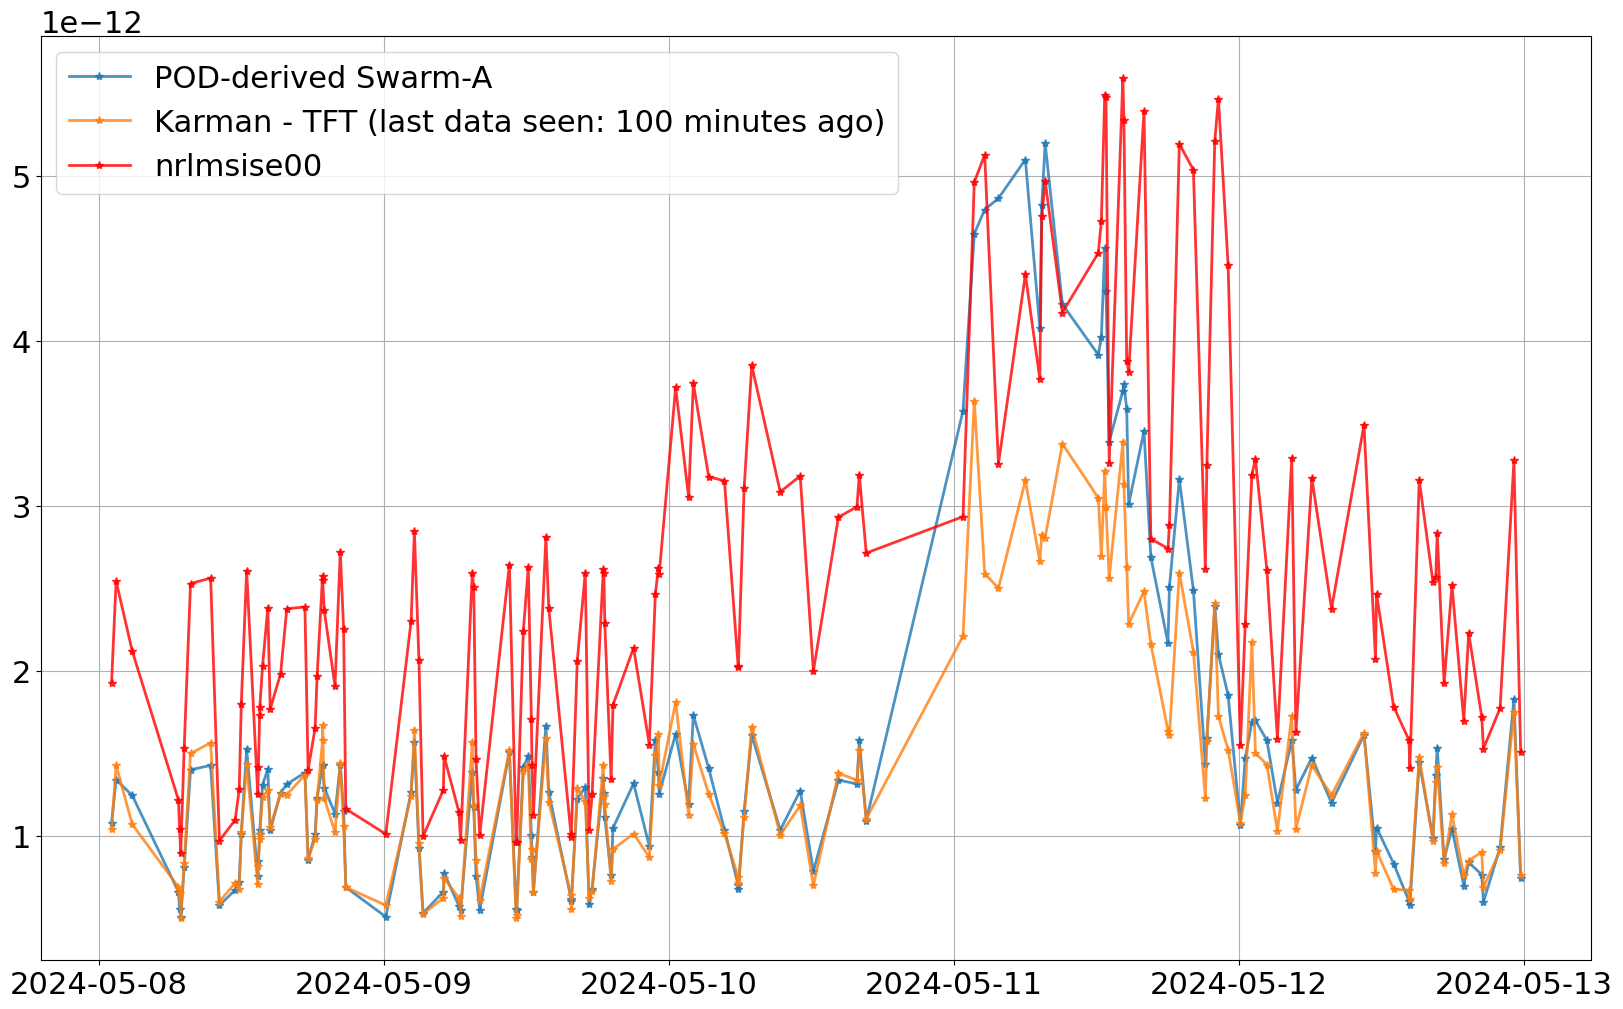

In [64]:
import matplotlib.pyplot as plt
import matplotlib
#change fontsize
matplotlib.rcParams.update({'font.size': 22})
plt.figure(figsize=(20,12))
plt.plot(dates[holdout_indices],
         target,
         '-*',
         alpha=0.8,
         label='POD-derived Swarm-A',
         linewidth=2.)
plt.plot(dates[holdout_indices],
         rho_nn,
         '-*',
         alpha=0.8,
         label=f'Karman - TFT (last data seen: {resolution_minutes} minutes ago)',
         linewidth=2.)
plt.plot(pd.to_datetime(karman_dataset.data_thermo['data']['all__dates_datetime__'].loc[holdout_indices].values),
         rho_nrlmsise00,
         '-*',
         alpha=0.8,
         label='nrlmsise00',
         linewidth=2.,
         color='red')
plt.legend(loc='upper left')
plt.grid()

## 3rd Option - Karman as global forecasting model

Here we do the inference by creating lat/lon grids and datetimes from scratch, as well as space weather-related inputs, and calling the model.

In [24]:
def find_sw_from_thermo(df_thermo, dates):
    # Ensure dates are in the same format
    dates = pd.to_datetime(dates).strftime("%Y-%m-%d")
    
    # Convert the DataFrame's index to a list of dates in 'YYYY-MM-DD' format
    dates_thermo = pd.to_datetime(df_thermo.index).strftime("%Y-%m-%d")
    
    # Create a boolean mask for the rows where the date matches any of the input dates
    mask = dates_thermo.isin(dates)
    
    # Use the mask to filter the DataFrame
    result_df = df_thermo[mask].copy()
    
    # Ensure that repeated dates in the input list are reflected in the result
    result_df = result_df.loc[result_df.index.repeat(dates_thermo[mask].map(dates.value_counts().to_dict()).fillna(0).astype(int))]
    
    return result_df

In [25]:
df_thermo=pd.read_parquet('../data_parquet/thermo_subsampled_daily.parquet')


In [64]:
from sklearn.preprocessing import QuantileTransformer

def scale_density(density,normalization_dict):
    tmp = torch.log10(density)
    log_min=normalization_dict['log_density']['min']
    log_max=normalization_dict['log_density']['max']
    return 2. * (tmp - log_min) / (log_max - log_min) - 1.

import math
def date_to_index(date, date_start, delta_seconds):
    delta_date = date - date_start
    
    #if it's not a vector, we can just return the index:
    return math.floor(delta_date.total_seconds() / delta_seconds)

def get_normalized_time_series(time_series_data_normalized,
                                start_date,
                                resolution,
                                lag,
                                date
                               ):
    now_index = date_to_index(pd.to_datetime(date), 
                                   start_date,
                                    60 * resolution)
    lagged_index = date_to_index(pd.to_datetime(date) - pd.Timedelta(minutes=lag),
                                        start_date,
                                        60 * resolution,)
    return time_series_data_normalized[lagged_index : (now_index + 1), :]

#getter for time series data:
def normalize_time_series_data(resolution,
                                data_path,
                                scalers_dict
                         ):
        data_names=data_path.keys()
        # Data loading:
        time_series_data={}
        for data_name in data_names:
            time_series_data[data_name] = {}
            if data_name in ["omni_indices", "omni_solar_wind", "omni_magnetic_field","goes_256nm","goes_284nm","goes_304nm","goes_1175nm","goes_1216nm","goes_1335nm","goes_1405nm","soho"]:
                data = pd.read_csv(data_path[data_name])
                # we now index the data by the datetime column, and sort it by the index. The reason is that it is then easier to resample
                start_date=data["all__dates_datetime__"].min()
                data.index = pd.to_datetime(data["all__dates_datetime__"])
                data.sort_index(inplace=True)
                # We exclude the columns that are not needed for the model.
                data = data.drop(columns=['all__dates_datetime__', 'source__gaps_flag__'], axis=1)
                # This is to remove significant outliers, such as the fism2 flare data which has 10^45 photons at one point. Regardless
                # of whther this is true or not, it severely affects the distribution.
                for column in data.columns:
                    quantile = data[column].quantile(0.998)
                    more_than = data[column] >= quantile
                    data.loc[more_than, column] = None
                # We replace NaNs and +/-inf by interpolating them away.
                data = data.replace([np.inf, -np.inf], None)
                data = data.interpolate(method="pad")
                # We resample the data to the chosen resolution. We use forward fill, to fill in the gaps. Another possibility is the mean.
                #time_series_data[data_name]['data'] = time_series_data[data_name]['data'].resample(f'{resolution}T').mean()
                data = (data.resample(f"{resolution}T").ffill())
                # We store the start date of the dataset, and the data matrix.
                values = data.values
                # We scale the data, and convert it to a torch tensor.
                values = scalers_dict[data_name].fit_transform(values)  # .astype(np.float32)
                values = torch.tensor(values,dtype=torch.float32).detach()
                time_series_data[data_name]['values']=values
                time_series_data[data_name]['start_date']=start_date
            elif data_name in ["msise"]:
                    data = pd.read_csv(data_path[data_name])
                    start_date=data["all__dates_datetime__"].min()
                    # we now index the data by the datetime column, and sort it by the index. The reason is that it is then easier to resample
                    data.index = pd.to_datetime(data["all__dates_datetime__"])
                    data.sort_index(inplace=True)
                    # We exclude the columns that are not needed for the model.
                    if 'source__gaps_flag__' in data.columns:
                         data = data.drop(columns=['all__dates_datetime__', 'source__gaps_flag__'], axis=1)
                    else:
                        data = data.drop(columns=['all__dates_datetime__'], axis=1)
                    # We resample the data to the chosen resolution. We use forward fill, to fill in the gaps. Another possibility is the mean.
                    #time_series_data[data_name]['data'] = time_series_data[data_name]['data'].resample(f'{resolution}T').mean()
                    data = (data.resample(f"{resolution}T").ffill())
                    # We store the start date of the dataset, and the data matrix.
                    values = torch.tensor(data.values,dtype=torch.float32).detach()
                    #let's normalize it - being a thermospheric density, this strategy is different than the other time series:
                    values=scale_density(values,normalization_dict_ts)
                    time_series_data[data_name]['values']=values
                    time_series_data[data_name]['start_date']=start_date
        return time_series_data

In [26]:
import pandas as pd
data_path={"omni_indices":'../data/omniweb_data/merged_omni_indices.csv', 
           "omni_solar_wind":'../data/omniweb_data/merged_omni_solar_wind.csv', 
           "omni_magnetic_field":'../data/omniweb_data/merged_omni_magnetic_field.csv',
           "soho":'../data/soho_data/soho_data.csv',
           "msise":'../data/nrlmsise00_data/nrlmsise00_time_series.csv'}

In [27]:
ts_data_normalized=normalize_time_series_data(resolution=resolution_minutes,
                                                data_path=data_path,
                                                scalers_dict=scalers_dict)

/var/tmp/ipykernel_3961361/1591649050.py:55: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.interpolate(method="pad")
/var/tmp/ipykernel_3961361/1591649050.py:58: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  data = (data.resample(f"{resolution}T").ffill())
/var/tmp/ipykernel_3961361/1591649050.py:55: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.interpolate(method="pad")
/var/tmp/ipykernel_3961361/1591649050.py:58: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  data = (data.resample(f"{resolution}T").ffill())
/var/tmp/ipykernel_3961361/1591649050.py:55: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use 

In [83]:
import pandas as pd

df_thermo=pd.read_parquet('../data_parquet/thermo_subsampled_daily.parquet')

def find_sw_from_thermo(df_thermo, dates):
    # Ensure dates are in the same format
    dates = pd.to_datetime(dates).strftime("%Y-%m-%d")
    
    # Convert the DataFrame's index to a list of dates in 'YYYY-MM-DD' format
    dates_thermo = pd.to_datetime(df_thermo.index).strftime("%Y-%m-%d")
    
    # Create a boolean mask for the rows where the date matches any of the input dates
    mask = dates_thermo.isin(dates)
    
    # Use the mask to filter the DataFrame
    result_df = df_thermo[mask].copy()
    
    # Ensure that repeated dates in the input list are reflected in the result
    result_df = result_df.loc[result_df.index.repeat(dates_thermo[mask].map(dates.value_counts().to_dict()).fillna(0).astype(int))]
    
    return result_df

In [84]:
def predict(dates, 
            altitudes,
            longitudes,
            latitudes,
            df_thermo,
            normalization_dict,
            device,
            ts_karman_model,
            ts_data_normalized,
            omni_indices,
            omni_magnetic_field,
            omni_solar_wind,
            soho,
            msise):
    """
    Performs the inference of the nowcasting model.

    Args:
        - dates (`list`): list of datetime objects
        - altitudes (`list`): list of altitudes (in meters)
        - longitudes (`list`): list of longitudes (in degrees, between -180-180)
        - latitudes (`list`): list of latitudes (in degrees, between -90, 90)
        - df_thermo (`pd.DataFrame`): pandas dataframe containing instantaneous features
        - normalization_dict (`dict`): dictionary containing the normalization parameters for the instantaenous features
        - device (`str`): device to run the model on ('cpu' or 'cuda')
        - ts_karman_model (`torch.nn.Module`): time series model
        - ts_data_normalized (`dict`): dictionary containing the normalized time series data
        - omni_indices (`dict`): dictionary containing the parameters for the omni indices
        - omni_magnetic_field (`dict`): dictionary containing the parameters for the omni magnetic field
        - omni_solar_wind (`dict`): dictionary containing the parameters for the omni solar wind
        - soho (`dict`): dictionary containing the parameters for the SOHO data
        - msise (`dict`): dictionary containing the parameters for the NRLMSISE-00 data
        
    """
    dates=pd.to_datetime(dates)
    sw=find_sw_from_thermo(df_thermo,dates)

    doy=torch.tensor(dates.dayofyear,dtype=torch.float32)
    #doy = date.timetuple().tm_yday
    sid = torch.tensor(dates.hour * 3600 + dates.minute * 60 + dates.second + dates.microsecond / 1e6,dtype=torch.float32)
    feature_as_radian = (2* np.pi * (doy-normalization_dict['all__day_of_year__[d]']["min"])/ (normalization_dict['all__day_of_year__[d]']["max"] - normalization_dict['all__day_of_year__[d]']["min"]))
    all_doy_sin=feature_as_radian.sin()
    all_doy_cos=feature_as_radian.cos()

    feature_as_radian = (2* np.pi * (sid-normalization_dict['all__seconds_in_day__[s]']["min"])/ (normalization_dict['all__seconds_in_day__[s]']["max"] - normalization_dict['all__seconds_in_day__[s]']["min"]))
    sid_sin=feature_as_radian.sin()
    sid_cos=feature_as_radian.cos()

    lon=torch.tensor(longitudes)
    lon_sin=torch.deg2rad(lon).sin()
    lon_cos=torch.deg2rad(lon).cos()

    inputs={}
    static_features=[]
    alt_n=2*(torch.tensor(altitudes)-normalization_dict['tudelft_thermo__altitude__[m]']["min"])/(normalization_dict['tudelft_thermo__altitude__[m]']["max"]-normalization_dict['tudelft_thermo__altitude__[m]']["min"])-1
    lat_n=2*(torch.tensor(latitudes)-normalization_dict['tudelft_thermo__latitude__[deg]']["min"])/(normalization_dict['tudelft_thermo__latitude__[deg]']["max"]-normalization_dict['tudelft_thermo__latitude__[deg]']["min"])-1
    static_features.append(alt_n)
    static_features.append(lat_n)
    for feature in normalization_dict.keys():
        if feature not in ['all__day_of_year__[d]', 
                           'all__seconds_in_day__[s]', 
                           'tudelft_thermo__longitude__[deg]',
                           'tudelft_thermo__altitude__[m]',
                           'tudelft_thermo__latitude__[deg]',
                           'log_density']:
            try:
                feature_sw=feature.split('__')[-2]
                static_features.append(2*(torch.tensor(sw[feature_sw])-normalization_dict[feature]["min"])/(normalization_dict[feature]["max"]-normalization_dict[feature]["min"])-1)
            except Exception as e:
                print(f"Note, {feature_sw} not found in the sw dictionary, you have to use: f107_obs, f107_average, s107_obs, s107_average, m107_obs, m107_average, f107_obs, f107_average, ap_average, d_st_dt")
    static_features.append(lon_sin)
    static_features.append(lon_cos)
    static_features.append(all_doy_sin)
    static_features.append(all_doy_cos)
    static_features.append(sid_sin)
    static_features.append(sid_cos)
    static_features=torch.stack(static_features,axis=1)
    inputs['static_feats_numeric']=static_features.to(device)

    historical_ts_numeric=[]
    #NOTE: historical_ts_numeric has shape: n_elements x n_time_steps x n_features
    #      future_ts_numeric has shape: n_elements x n_time_steps x n_features (we usually assume n_time_steps to be 1 here)
    #      static_feats_numeric has shape: n_elements x n_features
    if omni_indices["lag"] is not None and omni_indices["resolution"] is not None:
        #here I do this radomly, TODO -> do this via pulling from the database directly and then using the scaler to normalize:
        num_temporal=int(omni_indices["lag"]/omni_indices["resolution"])
        omni_indices_inputs=[]
        for date in dates:
            omni_indices_inputs.append(get_normalized_time_series(ts_data_normalized["omni_indices"]["values"],
                                                                pd.to_datetime(ts_data_normalized["omni_indices"]['start_date']),
                                                                resolution=resolution_minutes,
                                                                lag=lag_minutes,
                                                                date=date)[:-1,:])
        omni_indices_inputs=torch.cat(omni_indices_inputs).reshape((len(dates),num_temporal,ts_data_normalized["omni_indices"]["values"].shape[1]))
        historical_ts_numeric+=[omni_indices_inputs]

    if omni_magnetic_field["lag"] is not None and omni_magnetic_field["resolution"] is not None:
        #here I do this radomly, TODO -> do this via pulling from the database directly and then using the scaler to normalize:
        num_temporal=int(omni_magnetic_field["lag"]/omni_magnetic_field["resolution"])
        omni_magnetic_field_inputs=[]
        for date in dates:
            omni_magnetic_field_inputs.append(get_normalized_time_series(ts_data_normalized["omni_magnetic_field"]["values"],
                                                                pd.to_datetime(ts_data_normalized["omni_magnetic_field"]['start_date']),
                                                                resolution=resolution_minutes,
                                                                lag=lag_minutes,
                                                                date=date)[:-1,:])
        omni_magnetic_field_inputs=torch.cat(omni_magnetic_field_inputs).reshape((len(dates),num_temporal,ts_data_normalized["omni_magnetic_field"]["values"].shape[1]))
        historical_ts_numeric+=[omni_magnetic_field_inputs]
    if omni_solar_wind["lag"] is not None and omni_solar_wind["resolution"] is not None:
        #here I do this radomly, TODO -> do this via pulling from the database directly and then using the scaler to normalize:
        num_temporal=int(omni_solar_wind["lag"]/omni_solar_wind["resolution"])
        omni_solar_wind_inputs=[]
        for date in dates:
            omni_solar_wind_inputs.append(get_normalized_time_series(ts_data_normalized["omni_solar_wind"]["values"],
                                                                pd.to_datetime(ts_data_normalized["omni_solar_wind"]['start_date']),
                                                                resolution=resolution_minutes,
                                                                lag=lag_minutes,
                                                                date=date)[:-1,:])
        omni_solar_wind_inputs=torch.cat(omni_solar_wind_inputs).reshape((len(dates),num_temporal,ts_data_normalized["omni_solar_wind"]["values"].shape[1]))
        historical_ts_numeric+=[omni_solar_wind_inputs]

    if soho["lag"] is not None and soho["resolution"] is not None:
        #here I do this radomly, TODO -> do this via pulling from the database directly and then using the scaler to normalize:
        num_temporal=int(soho["lag"]/soho["resolution"])
        soho_inputs=[]
        for date in dates:
            soho_inputs.append(get_normalized_time_series(ts_data_normalized["soho"]["values"],
                                                                pd.to_datetime(ts_data_normalized["soho"]['start_date']),
                                                                resolution=resolution_minutes,
                                                                lag=lag_minutes,
                                                                date=date)[:-1,:])
        soho_inputs=torch.cat(soho_inputs).reshape((len(dates),num_temporal,ts_data_normalized["soho"]["values"].shape[1]))
        historical_ts_numeric+=[soho_inputs]

    if msise["lag"] is not None and msise["resolution"] is not None:
        #here I do this radomly, TODO -> do this via pulling from the database directly and then using the scaler to normalize:
        num_temporal=int(msise["lag"]/msise["resolution"])
        msise_inputs=[]
        msise_last=[]
        for date in dates:
            val=get_normalized_time_series(ts_data_normalized["msise"]["values"],
                                                                pd.to_datetime(ts_data_normalized["msise"]['start_date']),
                                                                resolution=resolution_minutes,
                                                                lag=lag_minutes,
                                                                date=date)
            msise_inputs.append(val[:-1,:])
            msise_last.append(val[-1,:])
        msise_inputs=torch.cat(msise_inputs).reshape((len(dates),num_temporal,ts_data_normalized["msise"]["values"].shape[1]))
        msise_last=torch.cat(msise_last).reshape((len(dates),1,ts_data_normalized["msise"]["values"].shape[1]))
        historical_ts_numeric+=[msise_inputs]

    if len(historical_ts_numeric)>1:
        historical_ts_numeric=torch.cat(historical_ts_numeric,dim=2)
    else:
        historical_ts_numeric=historical_ts_numeric[0]

    inputs['future_ts_numeric']=torch.tensor(np.random.rand(len(lon_sin),1,msise["num_features"]),dtype=torch.float32).to(device)
    inputs['historical_ts_numeric']=historical_ts_numeric.to(device)

    batch_out=ts_karman_model(inputs)       
    #now the quantiles for the tft:
    predicted_quantiles = batch_out['predicted_quantiles']#it's of shape batch_size x future_steps x num_quantiles
    target_nn_median=predicted_quantiles[:, :, 0].squeeze()
    rho_nn=karman_dataset.unscale_density(target_nn_median.detach().cpu()).numpy()

    return rho_nn

In [85]:
omni_indices={'lag':lag_minutes,'resolution': resolution_minutes, 'num_features': len(karman_dataset.time_series_data['omni_indices']['column_names'])}
omni_solar_wind={'lag':lag_minutes,'resolution': resolution_minutes, 'num_features': len(karman_dataset.time_series_data['omni_solar_wind']['column_names'])}
omni_magnetic_field={'lag':lag_minutes,'resolution': resolution_minutes, 'num_features': len(karman_dataset.time_series_data['omni_magnetic_field']['column_names'])}
soho={'lag':lag_minutes,'resolution': resolution_minutes, 'num_features': len(karman_dataset.time_series_data['soho']['column_names'])}
msise={'lag':lag_minutes,'resolution': resolution_minutes, 'num_features': len(karman_dataset.time_series_data['msise']['column_names'])}

In [86]:
# We build the model entries:
n_grid=100
u, v = np.linspace(0, 1, n_grid), np.linspace(0, 1, n_grid)
longitude, latitude = np.sort(2 * np.pi * u), np.sort(np.arccos(2 * v - 1) - np.pi / 2)
lonlat_grid = np.stack([*np.meshgrid(longitude, latitude, indexing="ij")], axis=2).reshape(-1, 2) 

In [87]:

#let's prepare the inputs to the model and run it:
longitudes=list(np.rad2deg(lonlat_grid[:,0],dtype=np.float32))
latitudes=list(np.rad2deg(lonlat_grid[:,1],dtype=np.float32))
n_samples=len(longitudes)
altitudes=[450000.]*n_samples#250km in meters
sw={}
dates=['2022-05-08 00:59:47']*n_samples

In [89]:
density_nn=predict(dates=dates, 
        altitudes=altitudes,
        longitudes=longitudes,
        latitudes=latitudes,
        df_thermo=df_thermo,
        normalization_dict=normalization_dict_ts,
        omni_indices=omni_indices,
        omni_magnetic_field=omni_magnetic_field,
        omni_solar_wind=omni_solar_wind,
        soho=soho,
        msise=msise,
        device=torch.device('cpu'),
        ts_data_normalized=ts_data_normalized,
        ts_karman_model=ts_karman_model
)

Plotting

In [ ]:
#TODO: run nrlmsise00 -> use the datetime -> sw inputs function to get the space weather inputs and then do:
#density_nrlmsise00=msise_flat(
#                               time=date,
#                               alt=altitudes[0]/1e3,
#                               lon=np.rad2deg(lonlat_grid[:, 0]),
#                               lat=np.rad2deg(lonlat_grid[:, 1]),
#                               f107a=sw['f107_average'][0],
#                               f107=sw['f107_obs'][0],
#                               ap=sw['ap_average'][0],
#                               )[:, 5]* 1e3

Text(0.5, 1.0, 'Karman Forecasting Prediction')

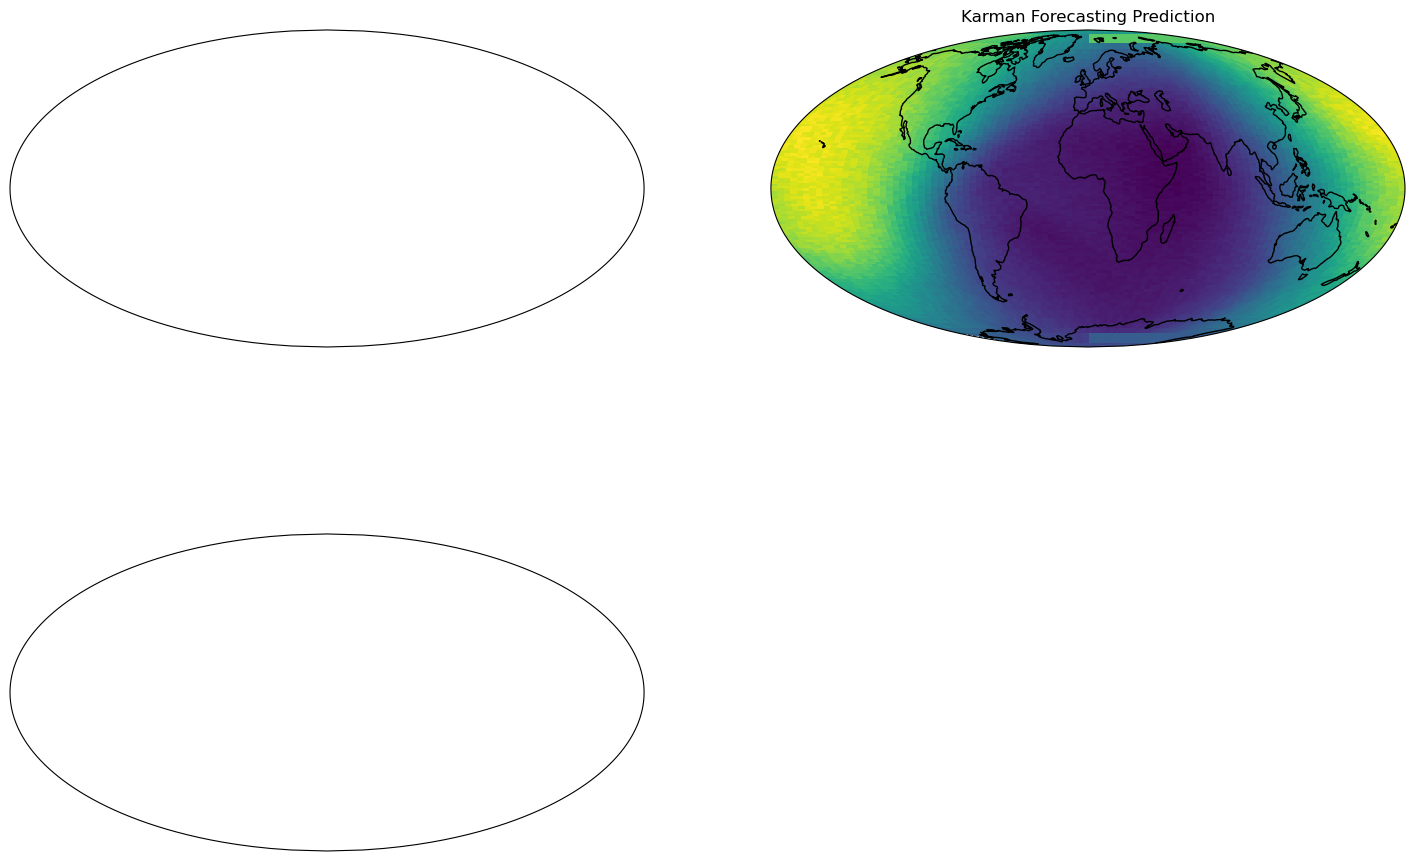

In [90]:
# we setup the longitude x latitude grid, and compute the relative error (in %)
lon_grid = np.rad2deg(lonlat_grid[:, 0].reshape((n_grid, n_grid)))
lat_grid = np.rad2deg(lonlat_grid[:, 1].reshape((n_grid, n_grid)))
#rel_err = ((density_nrlmsise00 - density_nn) / density_nn) * 100
# we print to scree the mean absolute percentage error on the globe map:
#print(
#    f"Average absolute relative percentage error on globe map: {abs(rel_err).mean()} %"
#)

# we now create a figure with a globe projection on top:
fig, ax = plt.subplots(
    figsize=(18, 12),
    nrows=2,
    ncols=2,
    subplot_kw={"projection": ccrs.Mollweide(central_longitude=0)},
)
# we flatten the axis and remove the last figure
ax = ax.ravel()
ax[-1].axis("off")

# we plot NRLMSISE-00 on the first figure:
#ax[0].pcolormesh(
#    lon_grid,
#    lat_grid,
#    density_nrlmsise00.reshape((n_grid, n_grid)),
#    transform=ccrs.PlateCarree(),
#    vmin=min(density_nrlmsise00),
#    vmax=max(density_nrlmsise00),
#)
#ax[0].set_global()
#ax[0].coastlines()
## ax[0].gridlines()
#ax[0].set_title("NRLMSISE-00")

# the NN prediction on the second:
im2 = ax[1].pcolormesh(
    lon_grid,
    lat_grid,
    density_nn.reshape((n_grid, n_grid)),
    transform=ccrs.PlateCarree(),
    vmin=min(density_nn),
    vmax=max(density_nn),
)
ax[1].set_global()
ax[1].coastlines()
# ax[1].gridlines()
ax[1].set_title("Karman Forecasting Prediction")
# we add a shared colorbar for the first two figures:
#cax1 = fig.add_axes([0.93, 0.6, 0.02, 0.2])  # [left, bottom, width, height]
#cbar1 = plt.colorbar(im2, orientation="vertical", fraction=0.035, cax=cax1)
#cbar1.set_label("Thermospheric Density [kg/m$^3$]")

# we finally plot the relative error in the second row
#im3 = ax[2].pcolormesh(
#    lon_grid,
#    lat_grid,
#    rel_err.reshape((n_grid, n_grid)),
#    transform=ccrs.PlateCarree(),
#    cmap="inferno",
#)
#ax[2].set_global()
#ax[2].coastlines()

# and we add the colorbar for that:
#cax2 = fig.add_axes([0.51, 0.1, 0.02, 0.3])  # [left, bottom, width, height]
#cbar1 = plt.colorbar(im3, orientation="vertical", fraction=0.035, cax=cax2)
#cbar1.set_label("Relative Error [%]")